Etape 1 : Ingestion et nettoyage des données

SPY → marché actions américain
QQQ → Nasdaq / tech / growth
TLT → obligations américaines long terme
GLD → or
USO → pétrole

In [4]:
import yfinance as yf

tickers = ["SPY", "TLT", "GLD", "USO", "QQQ"] 


data = yf.download(tickers, period="5y", auto_adjust=True)["Close"] #prix au close
data


[*********************100%***********************]  5 of 5 completed


Ticker,GLD,QQQ,SPY,TLT,USO
Date,,,,,
2021-09-01,169.699997,369.348877,422.266113,125.293709,47.930000
2021-09-02,169.250000,369.174133,423.565277,125.840714,48.950001
2021-09-03,171.059998,370.309601,423.462463,124.696190,48.660000
2021-09-07,167.710007,370.833710,421.948425,123.644295,48.040001
2021-09-08,167.289993,369.542938,421.434357,124.485832,48.590000
...,...,...,...,...,...
2026-08-26,421.320007,711.369995,766.080017,83.300003,127.349998
2026-08-27,422.600006,721.109985,771.099976,83.129997,130.009995
2026-08-28,408.890015,716.429993,769.349976,82.879997,129.699997


In [5]:
#rendements journaliers
returns = data.pct_change().dropna()  #on supprime la premiere ligne elle sera vide



#sauvegarde
returns.to_parquet("returns.parquet")

returns

Ticker,GLD,QQQ,SPY,TLT,USO
Date,,,,,
2021-09-02,-0.002652,-0.000473,0.003077,0.004366,0.021281
2021-09-03,0.010694,0.003076,-0.000243,-0.009095,-0.005924
2021-09-07,-0.019584,0.001415,-0.003575,-0.008436,-0.012741
2021-09-08,-0.002504,-0.003481,-0.001218,0.006806,0.011449
2021-09-09,0.004423,-0.003440,-0.004280,0.012100,-0.017288
...,...,...,...,...,...
2026-08-26,-0.015768,0.000915,0.000222,-0.002037,0.009512
2026-08-27,0.003038,0.013692,0.006553,-0.002041,0.020887
2026-08-28,-0.032442,-0.006490,-0.002269,-0.003007,-0.002384


Etape 2 : Analyse exploratoire EDA

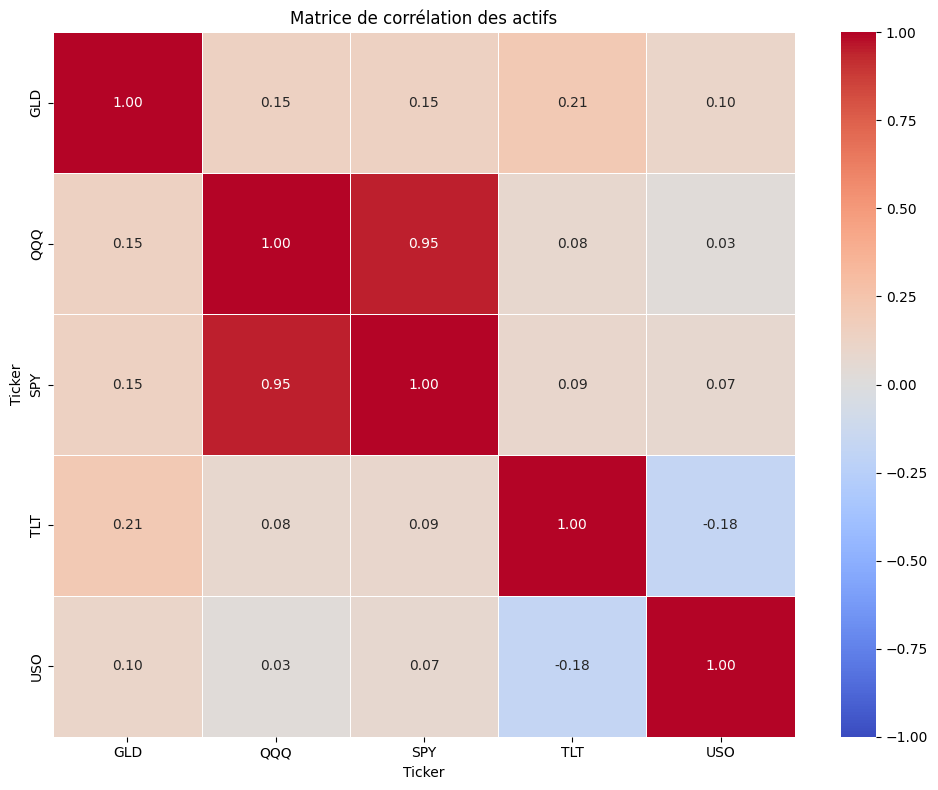

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

corr = returns.corr()

#matrice de correlation
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Matrice de corrélation des actifs")
plt.tight_layout()
plt.show()

On remarque qu'il n'ya presque pas de correlatrion entre les actifs (toute proche de 0), quoique les actions US et actions TECH sont évoluent fortement dans le même sens (0.95 proche de 1). Ce qui me semble logique car le marché des actions US est de loin majoritairement dominé par les grosses boîtes de TECH (NVIDIA, Apple, Microsoft...)

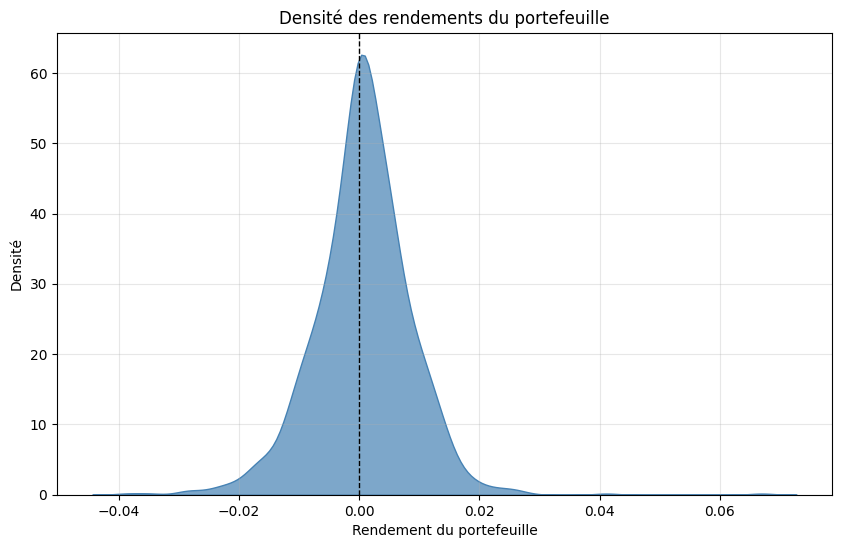

In [7]:
#courbe de densité des rendements du portefeuille
import numpy as np

# Portefeuille équipondéré 20%
poids = np.array([1/5, 1/5, 1/5, 1/5, 1/5])

#rendement du portefeuille  = somme pondérée des rendements
portfolio_return = returns.dot(poids)

# Courbe de densité
plt.figure(figsize=(10, 6))
sns.kdeplot(portfolio_return, fill="True", color="steelblue", alpha=0.7)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Densité des rendements du portefeuille")
plt.xlabel("Rendement du portefeuille")
plt.ylabel("Densité")
plt.grid(True, alpha=0.3)
plt.show()

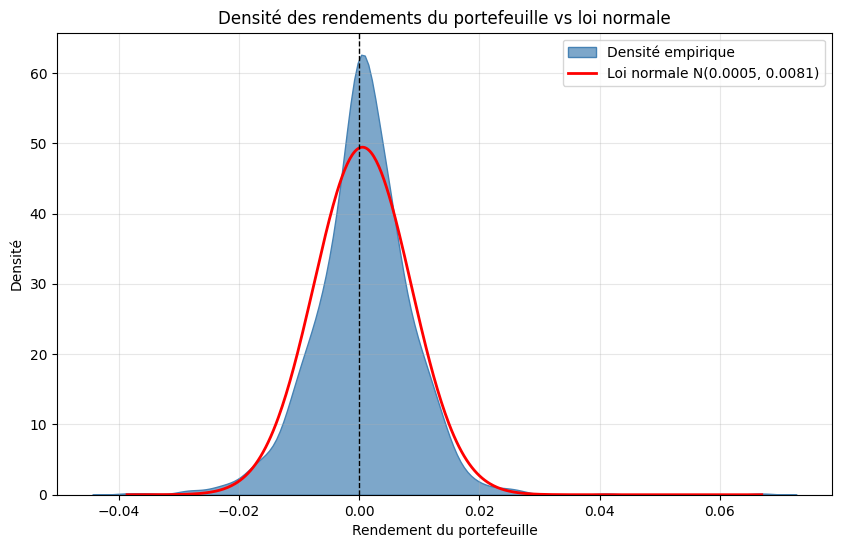

In [8]:
# superposition avec une loi normale de meme moyenne/ecart-type
from scipy import stats

#parametres de la loi normale
mu = portfolio_return.mean()
sigma = portfolio_return.std(ddof=1)

# Grille pour la courbe de densité normale
x = np.linspace(portfolio_return.min(), portfolio_return.max(), 500)

# Graphique
plt.figure(figsize=(10, 6))

# Densité empirique du portefeuille
sns.kdeplot(portfolio_return, fill=True, color="steelblue", alpha=0.7, label="Densité empirique")

# Loi normale de même moyenne / écart-type
plt.plot(
    x,
    stats.norm.pdf(x, loc=mu, scale=sigma),
    color="red",
    linewidth=2,
    label=f"Loi normale N({mu:.4f}, {sigma:.4f})"
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Densité des rendements du portefeuille vs loi normale")
plt.xlabel("Rendement du portefeuille")
plt.ylabel("Densité")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# Rendement du portefeuille (portefeuille équipondéré)
poids = np.array([1/5, 1/5, 1/5, 1/5, 1/5])
portfolio_return = returns.dot(poids)

# Skewness (asymétrie)
skewness = stats.skew(portfolio_return)

# Kurtosis (excès de kurtosis, par défaut dans scipy = Fisher)
kurtosis = stats.kurtosis(portfolio_return)

print(f"Skewness du portefeuille : {skewness:.6f}")
print(f"Kurtosis du portefeuille : {kurtosis:.6f}")

Skewness du portefeuille : 0.196462
Kurtosis du portefeuille : 5.074563
